In [ ]:
from fsl_mrs.utils import mrs_io
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%cd /Volumes/Kossowski/data/archive/FMRS2/test/test_met_7T/Dane_suma/019/019_STS/

/Volumes/Kossowski/data/archive/FMRS2/test/test_met_7T/Dane_suma/019/019_STS


In [3]:
%pwd
results_dir = 'fsl_mrs_quant'
import pandas as pd
import json

from fsl_mrs.utils import results, mrs_io, misc
from fsl_mrs.utils.baseline import prepare_baseline_regressor
from fsl_mrs.core.nifti_mrs import gen_nifti_mrs


# Read all_parameters.csv into pandas DF
param_df = pd.read_csv(results_dir + '/all_parameters.csv')

# Read options.txt
with open(results_dir + '/options.txt', "r") as f:
    orig_args = json.loads(f.readline())

# Load data into mrs object
FID = mrs_io.read_FID(orig_args['data'])
basis = mrs_io.read_basis(orig_args['basis'])

# Instantiate MRS object
mrs = FID.mrs(basis=basis)
if orig_args['conjfid'] is None:
    mrs.check_FID(repair=True)
elif orig_args['conjfid']:
    mrs.conj_FID = True
else:
    mrs.conj_FID = False

if orig_args['conjbasis'] is None:
    mrs.check_Basis(repair=True)
elif orig_args['conjbasis']:
    mrs.conj_Basis = True
else:
    mrs.conj_Basis = False

if not orig_args['no_rescale']:
    mrs.rescaleForFitting(ind_scaling=orig_args['ind_scale'])
mrs.keep = orig_args['keep']
mrs.ignore = orig_args['ignore']

if orig_args['lorentzian']:
    model = 'lorentzian'
else:
    model = 'voigt'

method = orig_args['algo']
# Generate metabolite groups
metab_groups = misc.parse_metab_groups(mrs, orig_args['metab_groups'])
baseline_order = orig_args['baseline_order']
if baseline_order < 0:
    baseline_order = 0  # Required to make prepare_baseline_regressor run.
ppmlim = orig_args['ppmlim']
# Generate baseline polynomials (B)
B = prepare_baseline_regressor(mrs, baseline_order, ppmlim)

# Generate results object
print(metab_groups)
res = results.FitRes(
    mrs,
    param_df['mean'].to_numpy(),
    model,
    method,
    metab_groups,
    baseline_order,
    B,
    ppmlim)


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [6]:
from fsl_mrs.utils import plotting as plot
plot.plot_indiv_stacked(mrs,res)

In [7]:
from fsl_mrs.utils.misc import FIDToSpec

axis = mrs.getAxes()
fit = np.real(FIDToSpec(mrs.FID))
cr = np.real(FIDToSpec(res.predictedFID(mrs, mode='Cr', noBaseline=True)))
glu = np.real(FIDToSpec(res.predictedFID(mrs, mode='Glu', noBaseline=True)))
gaba = np.real(FIDToSpec(res.predictedFID(mrs, mode='GABA', noBaseline=True)))

(4.5, 0.2)

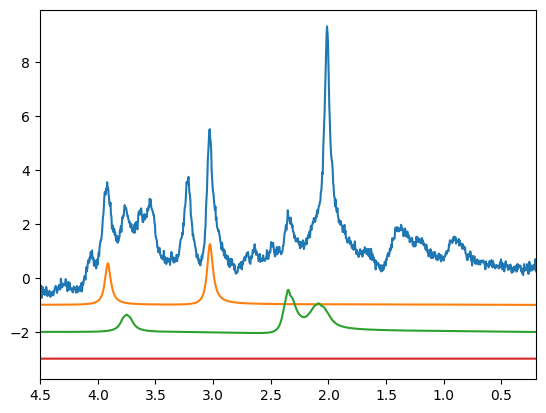

In [8]:
plt.plot(axis,fit)
plt.plot(axis,cr-1)
plt.plot(axis,glu-2)
plt.plot(axis,gaba-3)

plt.xlim(4.5,0.2)
#plt.ylabel('') etc
